## Importing Packages

In [1]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [2]:
year = 2024
race = "Sao Paulo Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (410.36 MB) C:\Users\odath\AppData\Local\Temp\fastf1
events      WARNING 	Correcting user input 'Sao Paulo Grand Prix' to 'São Paulo Grand Prix'
core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 

## Loading and Preparing Lap Data

In [3]:
laps = session.laps
laps = laps.sort_values(['Driver', 'LapNumber'])
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
207,0 days 01:13:32.364000,ALO,14,0 days 00:01:37.318000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:48.677000,...,Aston Martin,0 days 01:11:54.770000,2024-11-03 15:49:57.516,12,8.0,False,,False,False,97.318
208,0 days 01:14:59.480000,ALO,14,0 days 00:01:27.116000,2.0,1.0,NaT,NaT,0 days 00:00:22.133000,0 days 00:00:46.422000,...,Aston Martin,0 days 01:13:32.364000,2024-11-03 15:51:35.110,1,8.0,False,,False,True,87.116
209,0 days 01:16:26.446000,ALO,14,0 days 00:01:26.966000,3.0,1.0,NaT,NaT,0 days 00:00:22.158000,0 days 00:00:46.269000,...,Aston Martin,0 days 01:14:59.480000,2024-11-03 15:53:02.226,1,8.0,False,,False,True,86.966
210,0 days 01:17:53.166000,ALO,14,0 days 00:01:26.720000,4.0,1.0,NaT,NaT,0 days 00:00:22.118000,0 days 00:00:46.210000,...,Aston Martin,0 days 01:16:26.446000,2024-11-03 15:54:29.192,12,8.0,False,,False,True,86.720
211,0 days 01:19:19.210000,ALO,14,0 days 00:01:26.044000,5.0,1.0,NaT,NaT,0 days 00:00:22.127000,0 days 00:00:45.395000,...,Aston Martin,0 days 01:17:53.166000,2024-11-03 15:55:55.912,1,8.0,False,,False,True,86.044


## Compound color map

In [4]:
COMPOUND_COLORS = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FFD700',
    'HARD': "#C6BFBF",
    'INTERMEDIATE': '#39B54A',
    'WET': '#0077FF'
}

## Race Statergy Comparison between different drivers

In [5]:
results = session.results
dnf_drivers = session.results[
    (session.results['Position'].isna()) |
    (session.results['Status'].str.contains('Crash|Accident|Engine|Retired|Gearbox|Did not start|Mechanical|Collision damage|Disqualified|Hydraulics|Exhaust|Suspension|Overheating|Power Unit', na=False))
]['Abbreviation'].tolist()

session.results['Status'].head(22)

1          Finished
31         Finished
10         Finished
63         Finished
16         Finished
4          Finished
22         Finished
81         Finished
30         Finished
44         Finished
11         Finished
50         Finished
77         Finished
14         Finished
24         Finished
55          Retired
43          Retired
23    Did not start
18    Did not start
27     Disqualified
Name: Status, dtype: object

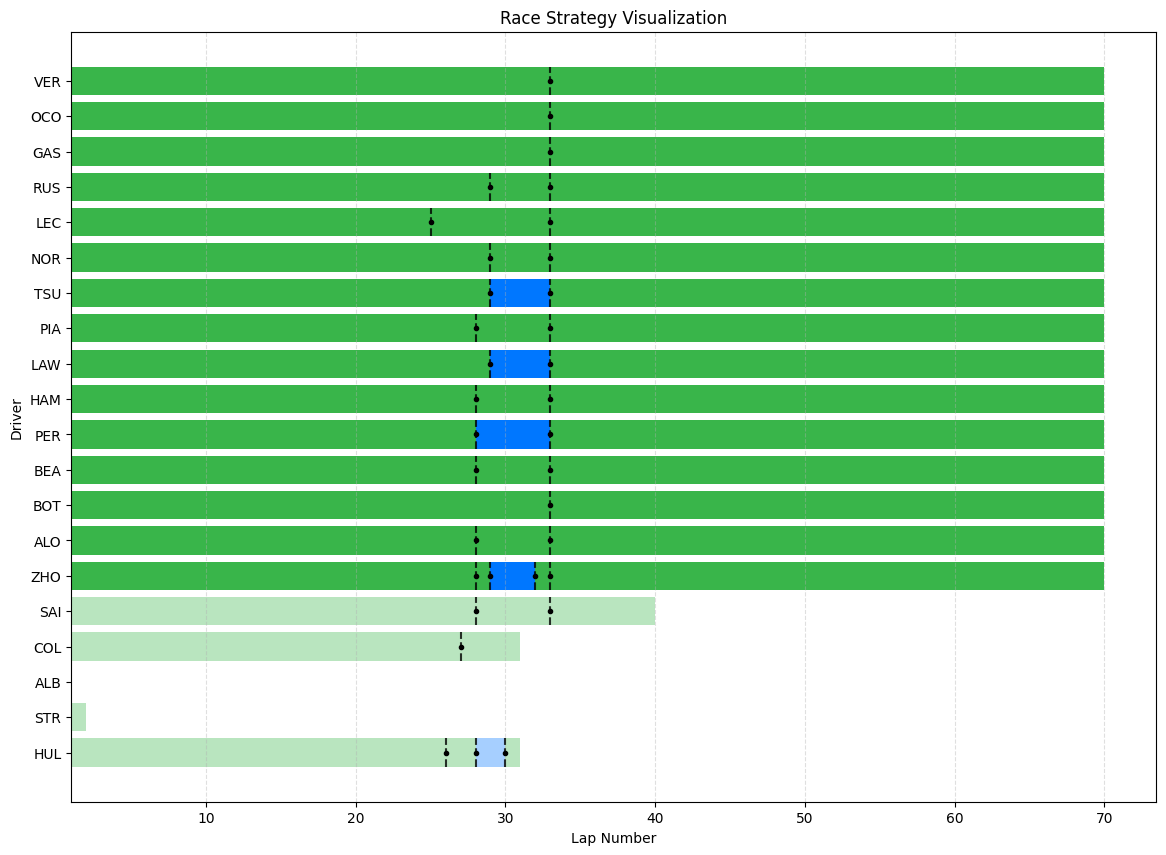

In [6]:
# Get finishing order
finishing_order = session.results.sort_values('Position')['Abbreviation'].tolist()
drivers = finishing_order[::-1]  # P1 at bottom

results = session.results
dnf_drivers = session.results[
    (session.results['Position'].isna()) |
    (session.results['Status'].str.contains('Oil leak|Water pressure|Power Unit|Suspension|Brakes|Collision|Accident|Engine|Retired|Gearbox|Did not start|Collision damage|Mechanical|Disqualified|Hydraulics|Exhaust|Suspension|Overheating|Power Unit', na=False))
]['Abbreviation'].tolist()


y_positions = {driver: i for i, driver in enumerate(drivers)}

fig, ax = plt.subplots(figsize=(14,10))

for driver in drivers:
    driver_laps = laps[laps['Driver'] == driver]
    stints = driver_laps.groupby('Stint')

    alpha = 0.35 if driver in dnf_drivers else 1.0
    y = y_positions[driver]

    for stint, data in stints:
        compound = data['Compound'].mode()[0]
        width = data['LapNumber'].max() - data['LapNumber'].min() + 1

        ax.barh(
            y,
            width,
            left=data['LapNumber'].min(),
            color=COMPOUND_COLORS.get(compound, '#AAAAAA'),
            alpha=alpha
        )

    # Pit stop markers
    pit_laps = driver_laps.loc[
        driver_laps['Stint'].diff() == 1, 'LapNumber'
    ]

    for lap in pit_laps:
        ax.plot(lap, y, marker='o', color='black', markersize=3, zorder=6)
        ax.vlines(
            lap,
            y - 0.4,
            y + 0.4,
            colors='black',
            linestyles='dashed',
            linewidth=1.5,
            alpha=0.8,
            zorder=5
        )

# Fix y-axis labels
ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Driver")
ax.set_title("Race Strategy Visualization")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()